# Phase 4 — Training Curves
Visualise loss, accuracy, AUC, precision, and recall across epochs.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
ROOT = Path("..")

with open(ROOT / "models/training_history_v1.json") as f:
    history = json.load(f)

with open(ROOT / "models/training_config_v1.json") as f:
    config = json.load(f)

print(f"Epochs trained : {config['epochs_trained']}")
print(f"Features       : {config['n_features']}")
print(f"Train samples  : {config['train_samples']}")
epochs = range(1, config['epochs_trained'] + 1)

Epochs trained : 80
Features       : 13
Train samples  : 7000


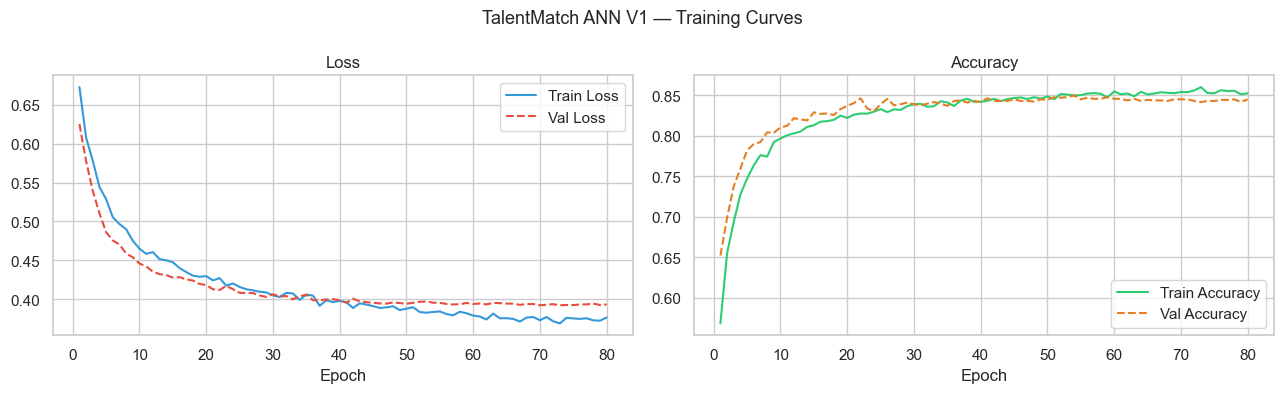

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history["loss"],     label="Train Loss", color="#3498db")
axes[0].plot(epochs, history["val_loss"], label="Val Loss",   color="#e74c3c", linestyle="--")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["accuracy"],     label="Train Accuracy", color="#2ecc71")
axes[1].plot(epochs, history["val_accuracy"], label="Val Accuracy",   color="#e67e22", linestyle="--")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle("TalentMatch ANN V1 — Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "screenshots/training_curves.png", dpi=150)
plt.show()

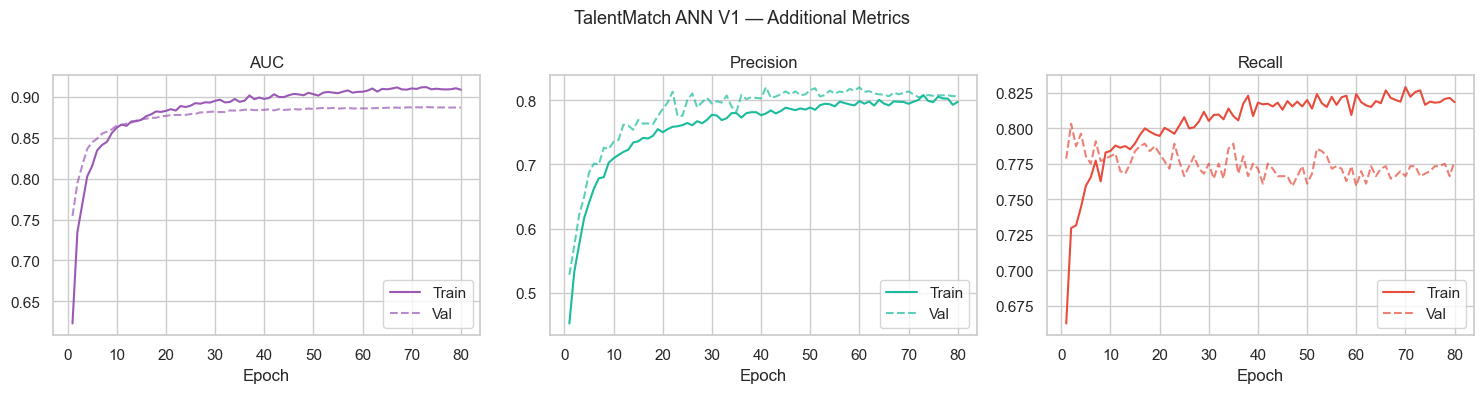

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ("auc",       "val_auc",       "AUC",       "#9b59b6"),
    ("precision", "val_precision", "Precision", "#1abc9c"),
    ("recall",    "val_recall",    "Recall",    "#e74c3c"),
]

for ax, (train_key, val_key, title, color) in zip(axes, metrics):
    ax.plot(epochs, history[train_key], label=f"Train", color=color)
    ax.plot(epochs, history[val_key],   label=f"Val",   color=color, linestyle="--", alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

plt.suptitle("TalentMatch ANN V1 — Additional Metrics", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "screenshots/training_metrics.png", dpi=150)
plt.show()

In [4]:
print("── Best Epoch Results ───────────────────────────")
best_epoch = np.argmin(history["val_loss"]) + 1
print(f"   Best epoch     : {best_epoch}")
print(f"   Val Loss       : {min(history['val_loss']):.4f}")
print(f"   Val Accuracy   : {history['val_accuracy'][best_epoch-1]:.4f}")
print(f"   Val AUC        : {history['val_auc'][best_epoch-1]:.4f}")
print(f"   Val Precision  : {history['val_precision'][best_epoch-1]:.4f}")
print(f"   Val Recall     : {history['val_recall'][best_epoch-1]:.4f}")

── Best Epoch Results ───────────────────────────
   Best epoch     : 70
   Val Loss       : 0.3922
   Val Accuracy   : 0.8447
   Val AUC        : 0.8873
   Val Precision  : 0.8134
   Val Recall     : 0.7663
